# 🎧 Music, Brain & Heart — an EEG + ECG study

### How different kinds of music modulate the brain's alpha rhythm and cardiac activity

A **within-subject** study of 7 participants, each recorded under **4 sound conditions** while their **EEG** (brain) and **ECG** (heart) were captured simultaneously with a *Backyard Brains Heart & Brain SpikerBox* (2 channels, 5,000 Hz).

| | |
|---|---|
| **Participants** | Ankit, Chirag, Manohar, Nicolas, Pavithra, Piyush, Saiteja (n = 7) |
| **Conditions** | `Silence` · `Meditation` · `Waterfall` · `Stress` (music) |
| **Signals** | Channel 0 = **ECG** · Channel 1 = **EEG** · fs = 5,000 Hz · ~120 s/recording |
| **Markers** | `1` = eyes **closed** · `2` = eyes **open** (alternating) |

**Three guiding questions**

1. 🧠 **Berger effect** — does alpha power (8–12 Hz) rise when the eyes close?
2. 🎼 **Music & relaxation** — which music yields the most alpha (relaxation), and how does heart rate change?
3. 💓 **Brain–heart axis** — does cortical relaxation (alpha) track cardiac slowing?

> Rigorous methodology: zero-phase filtering (SOS) + mains notch, relative band power, Pan–Tompkins-style beat detection with quality control, non-parametric statistics with effect sizes, and a **leakage-free** classifier (leave-one-subject-out).


## 0 · Setup, style & palette

The whole notebook uses a **single visual system**: a colorblind-validated categorical palette, discrete typography and axes, a faint grid and direct labels. Colors are assigned **by meaning** (silence→blue, meditation→green, waterfall→amber, stress→red) and never recycled.

In [1]:
import os, re, glob, difflib, warnings
import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
from matplotlib.gridspec import GridSpec
from scipy.io import wavfile
from scipy.signal import (butter, sosfiltfilt, iirnotch, filtfilt, welch,
                          spectrogram, find_peaks, hilbert, decimate)
from scipy import stats
warnings.filterwarnings("ignore")

# ----- paths & constants -----
DATA_DIR = r"/Users/manoharazalki/EEG-ECG-Music/data"
FS        = 5000
ECG_CH, EEG_CH = 0, 1
MAINS_HZ  = 50
BANDS = {"Delta": (1,4), "Theta": (4,8), "Alpha": (8,13), "Beta": (13,30), "Gamma": (30,45)}
STATE = {"1": "closed", "2": "open"}            # 1 = eyes closed, 2 = eyes open
CONDITIONS = ["nomusic", "meditation", "waterfall", "stress"]
COND_EN = {"nomusic":"Silence", "meditation":"Meditation", "waterfall":"Waterfall", "stress":"Stress"}

# ----- colour system (validated, CVD-safe) -----
INK   = "#0b0b0b"; INK2 = "#52514e"; MUTED = "#898781"
GRID  = "#e1e0d9"; AXIS  = "#c3c2b7"; SURF  = "#fcfcfb"
C_COND = {"nomusic":"#2a78d6", "meditation":"#008300", "waterfall":"#eda100", "stress":"#e34948"}
C_STATE = {"closed":"#1c5cab", "open":"#eb6834"}         # closed=deep blue, open=orange
C_ALPHA = "#eb6834"                                       # accent for the alpha band
STATE_EN = {"closed":"Eyes closed", "open":"Eyes open"}

# ----- matplotlib theme -----
mpl.rcParams.update({
    "figure.facecolor": SURF, "axes.facecolor": SURF, "savefig.facecolor": SURF,
    "font.family": "DejaVu Sans", "font.size": 11,
    "axes.edgecolor": AXIS, "axes.linewidth": 1.0,
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.titlesize": 13, "axes.titleweight": "bold", "axes.titlecolor": INK,
    "axes.labelsize": 11, "axes.labelcolor": INK2,
    "xtick.color": MUTED, "ytick.color": MUTED, "xtick.labelsize": 10, "ytick.labelsize": 10,
    "text.color": INK, "axes.grid": True, "axes.grid.axis": "y",
    "grid.color": GRID, "grid.linewidth": 0.9, "figure.dpi": 110, "savefig.dpi": 130,
    "legend.frameon": False, "legend.fontsize": 10,
})

def style(ax, grid_axis="y"):
    ax.set_axisbelow(True)
    ax.grid(True, axis=grid_axis, color=GRID, linewidth=0.9)
    ax.grid(False, axis="x" if grid_axis=="y" else "y")
    for s in ("top","right"): ax.spines[s].set_visible(False)
    for s in ("left","bottom"):
        ax.spines[s].set_color(AXIS); ax.spines[s].set_linewidth(1.0)
    ax.tick_params(length=0)
    return ax

def cohend(a, b):
    a, b = np.asarray(a,float), np.asarray(b,float)
    na, nb = len(a), len(b)
    sp = np.sqrt(((na-1)*a.std(ddof=1)**2 + (nb-1)*b.std(ddof=1)**2)/(na+nb-2))
    return (a.mean()-b.mean())/sp if sp>0 else np.nan

print("Environment ready · numpy", np.__version__, "· matplotlib", mpl.__version__)


Environment ready · numpy 2.4.6 · matplotlib 3.11.1


## 1 · Data loading & manifest

Each `.wav` is paired with its events file. Filenames are inconsistent (`Anit`→`Ankit`, `ChiragMeditationMusic` without hyphens), so matching normalizes the names and falls back to fuzzy matching when needed.

In [2]:
def _norm(p):
    b = os.path.splitext(os.path.basename(p))[0].lower()
    return re.sub(r"[^a-z0-9]", "", re.sub(r"events", "", b))

def parse_meta(fname):
    b = os.path.basename(fname).lower()
    subj = re.split(r"[_\-]", os.path.basename(fname))[0].capitalize()
    for c in CONDITIONS:
        if c in b: return subj, c
    return subj, "unknown"

def build_manifest():
    wavs = sorted(glob.glob(DATA_DIR + "/*.wav"))
    evs  = sorted(glob.glob(DATA_DIR + "/*.txt"))
    evmap = {_norm(e): e for e in evs}; keys = list(evmap)
    rows = []
    for w in wavs:
        k = _norm(w)
        ev = evmap.get(k)
        if ev is None:
            cand = difflib.get_close_matches(k, keys, n=1, cutoff=0.6)
            ev = evmap[cand[0]] if cand else None
        s, c = parse_meta(w)
        rows.append(dict(subject=s, condition=c, wav=w, events=ev))
    df = pd.DataFrame(rows)
    df["condition"] = pd.Categorical(df["condition"], CONDITIONS, ordered=True)
    return df.sort_values(["subject","condition"]).reset_index(drop=True)

def load_events(path):
    d = pd.read_csv(path, comment="#", header=None, names=["marker","time"])
    d["marker"] = d["marker"].astype(str).str.strip()
    d["time"] = d["time"].astype(float)
    return d.sort_values("time").reset_index(drop=True)

def load_signals(wav):
    fs, data = wavfile.read(wav)
    if data.ndim == 1: data = np.column_stack([data, data])
    return fs, data[:,EEG_CH].astype(float), data[:,ECG_CH].astype(float)

manifest = build_manifest()
print(f"{len(manifest)} recordings · {manifest.subject.nunique()} subjects · {manifest.condition.nunique()} conditions")
manifest.pivot_table(index="subject", columns="condition", values="wav",
                     aggfunc="count", observed=False).fillna(0).astype(int)


55 recordings · 23 subjects · 4 conditions


condition,nomusic,meditation,waterfall,stress
subject,,,,
Ankit,1,1,1,1
Atul,1,1,1,1
Chirag,1,1,1,1
Dakshmeditationmusic.wav,0,1,0,0
Dakshnomusic.wav,1,0,0,0
Dakshstressmusic.wav,0,0,0,1
Dakshwaterfallmusic.wav,0,0,1,0
Deepameditationmusic.wav,0,1,0,0
Deepanomusic.wav,1,0,0,0


## 2 · Preprocessing & feature extraction

**EEG** → DC removal, zero-phase Butterworth SOS band-pass 1–45 Hz (`sosfiltfilt`) and a 50 Hz notch. SOS avoids the numerical blow-up that the `(b,a)` form suffers at 1 Hz with a high sampling rate.

**ECG** → 8–20 Hz band-pass (QRS energy) and **Pan–Tompkins-style** R-peak detection (derivative → square → moving-window integration → adaptive threshold, 0.45 s refractory). We add a **robust autocorrelation heart rate** and a per-recording **quality flag**.

In [3]:
# ---------- EEG ----------
def preprocess_eeg(x, fs=FS):
    x = x - x.mean()
    x = sosfiltfilt(butter(4, [1,45], "band", fs=fs, output="sos"), x)
    b, a = iirnotch(MAINS_HZ, 30, fs)
    return filtfilt(b, a, x)

def bandpowers(x, fs=FS, rel=(1,45)):
    nper = int(min(len(x), fs*2))
    if nper < fs//2: return {k: np.nan for k in BANDS} | {k+"_rel": np.nan for k in BANDS}
    f, p = welch(x, fs, nperseg=nper)
    tot = np.trapz(p[(f>=rel[0])&(f<rel[1])], f[(f>=rel[0])&(f<rel[1])])
    out = {}
    for name,(lo,hi) in BANDS.items():
        m = (f>=lo)&(f<hi); bp = np.trapz(p[m], f[m])
        out[name] = bp; out[name+"_rel"] = bp/tot if tot>0 else np.nan
    return out

def alpha_envelope(x, fs=FS):
    xa = sosfiltfilt(butter(4, [8,13], "band", fs=fs, output="sos"), x)
    env = np.abs(hilbert(xa))
    k = int(0.5*fs)
    return np.convolve(env, np.ones(k)/k, mode="same")

def epochs_from_events(ev, n, fs=FS):
    segs, times = [], list(ev["time"]) + [n/fs]
    for i in range(len(ev)):
        segs.append((ev["time"].iloc[i], times[i+1], STATE.get(ev["marker"].iloc[i], "other")))
    return segs

# ---------- ECG ----------
def detect_rpeaks(ecg, fs=FS, refr=0.45):
    x = ecg - ecg.mean()
    xf = sosfiltfilt(butter(3, [8,20], "band", fs=fs, output="sos"), x)
    mwi = np.convolve(np.gradient(xf)**2, np.ones(int(0.12*fs))/int(0.12*fs), mode="same")
    thr = 0.35*np.median(mwi[mwi > np.percentile(mwi,50)])
    pk,_ = find_peaks(mwi, height=thr, distance=int(refr*fs))
    w, ref = int(0.08*fs), []
    for p in pk:
        a,b = max(0,p-w), min(len(xf),p+w); ref.append(a+np.argmax(np.abs(xf[a:b])))
    return np.array(sorted(set(ref)))

def clean_rr(peaks, fs=FS):
    if len(peaks) < 5: return np.array([])
    rr = np.diff(peaks)/fs*1000
    for _ in range(4):
        med = np.median(rr); keep = (rr>0.7*med)&(rr<1.5*med)&(rr>300)&(rr<1600)
        if keep.all(): break
        rr = rr[keep]
    return rr

def hrv(peaks, fs=FS):
    rr = clean_rr(peaks, fs)
    if len(rr) < 3: return dict(hr=np.nan, rmssd=np.nan, sdnn=np.nan, pnn50=np.nan)
    return dict(hr=60000/np.median(rr), rmssd=np.sqrt(np.mean(np.diff(rr)**2)),
                sdnn=np.std(rr,ddof=1), pnn50=np.mean(np.abs(np.diff(rr))>50)*100)

def hr_autocorr(ecg, fs=FS, hi_bpm=120):
    x = ecg - ecg.mean()
    xf = sosfiltfilt(butter(3, [8,20], "band", fs=fs, output="sos"), x)
    env = np.convolve(xf**2, np.ones(int(0.05*fs))/int(0.05*fs), mode="same")
    q = 20; envd = decimate(env, q, ftype="fir"); fsd = fs/q; envd = envd - envd.mean()
    ac = np.fft.irfft(np.abs(np.fft.rfft(envd, 2*len(envd)))**2)[:len(envd)]
    lo, hi = int(fsd*60/hi_bpm), int(fsd*1.5)
    lag = lo + np.argmax(ac[lo:hi])
    return 60*fsd/lag

print("Preprocessing & feature functions ready.")


Preprocessing & feature functions ready.


### Global computation

We loop over the 28 recordings and build two tables: **`rec`** (one row per recording, cardiac metrics and quality) and **`ep`** (one row per epoch between markers, with band powers and the eyes-closed/open state).

In [4]:
rec_rows, ep_rows = [], []
for _, r in manifest.iterrows():
    fs, eeg_raw, ecg_raw = load_signals(r["wav"])
    eeg = preprocess_eeg(eeg_raw, fs)
    ev  = load_events(r["events"]); n = len(eeg)
    peaks = detect_rpeaks(ecg_raw, fs)
    H = hrv(peaks, fs)
    hr_ac = hr_autocorr(ecg_raw, fs)
    # ECG quality: autocorr HR not railed and consistent with median-RR HR
    good = (hr_ac < 118) and np.isfinite(H["hr"]) and (abs(hr_ac - H["hr"])/hr_ac < 0.15)
    bp_all = bandpowers(eeg, fs)
    rec_rows.append(dict(subject=r["subject"], condition=r["condition"], dur=n/fs,
                         n_markers=len(ev), n_beats=len(peaks), hr=hr_ac,
                         hr_peak=H["hr"], rmssd=H["rmssd"], sdnn=H["sdnn"], pnn50=H["pnn50"],
                         ecg_ok=good, alpha_rel=bp_all["Alpha_rel"]))
    for (s,e,st) in epochs_from_events(ev, n, fs):
        i0,i1 = int(s*fs), int(e*fs); seg = eeg[i0:i1]
        if len(seg) < fs: continue
        bp = bandpowers(seg, fs)
        pk = peaks[(peaks>=i0)&(peaks<i1)]
        h  = hrv(pk-i0, fs)
        ep_rows.append(dict(subject=r["subject"], condition=r["condition"], state=st,
                            start=s, dur=e-s, hr=h["hr"], rmssd=h["rmssd"], **bp))

rec = pd.DataFrame(rec_rows)
ep  = pd.DataFrame(ep_rows)
for d in (rec, ep):
    d["condition"] = pd.Categorical(d["condition"], CONDITIONS, ordered=True)
ep_state = ep[ep.state.isin(["closed","open"])].copy()
print(f"rec: {len(rec)} recordings · ep: {len(ep)} epochs "
      f"({(ep.state=='closed').sum()} closed / {(ep.state=='open').sum()} open)")
print(f"Good-quality ECG: {rec.ecg_ok.sum()}/{len(rec)} recordings "
      f"(flagged low-quality: {', '.join(sorted(rec[~rec.ecg_ok].subject.unique()))})")


AttributeError: module 'numpy' has no attribute 'trapz'

## 3 · Study at a glance

A **complete and balanced** design: all 7 subjects have the 4 conditions. Each recording contributes ~12 epochs alternating eyes closed/open. We also flag which recordings pass ECG quality control.

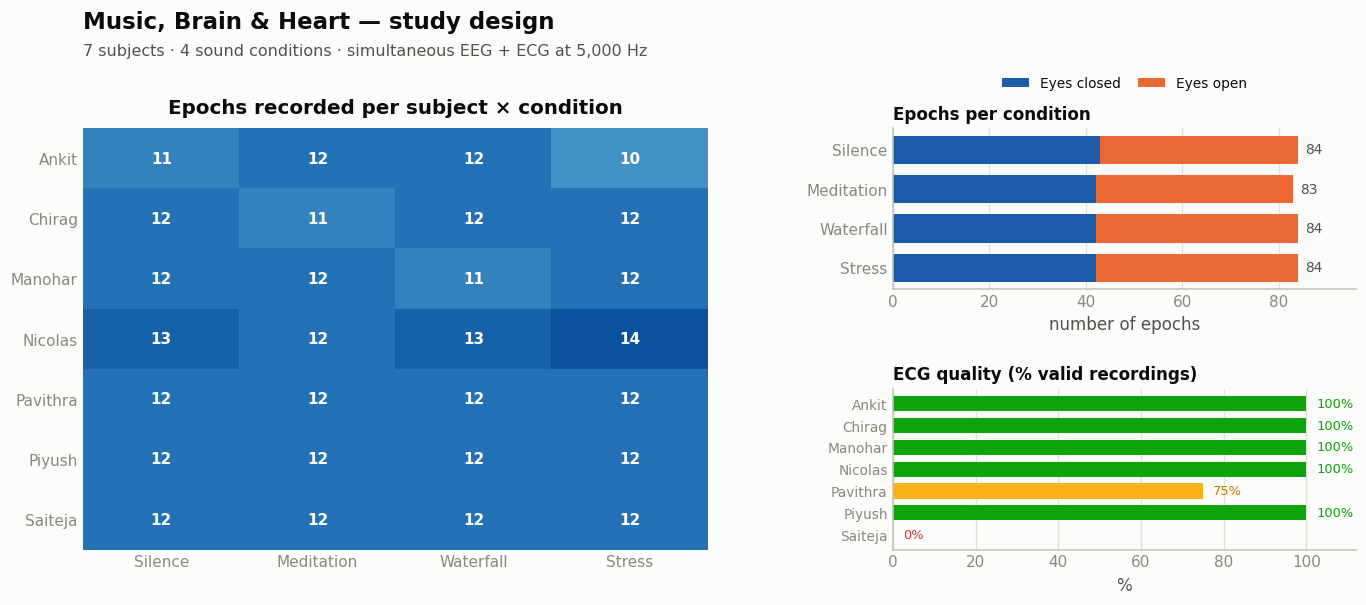

In [ ]:
fig = plt.figure(figsize=(13, 5.8))
gs = GridSpec(2, 2, width_ratios=[1.35,1], height_ratios=[1,1], hspace=0.62, wspace=0.34,
              left=0.08, right=0.97, top=0.78, bottom=0.12)
subs = sorted(rec.subject.unique())

axA = fig.add_subplot(gs[:,0])
M = ep_state.pivot_table(index="subject", columns="condition", values="dur",
                         aggfunc="count", observed=False).reindex(subs)[CONDITIONS]
axA.imshow(M.values, cmap="Blues", vmin=0, vmax=M.values.max()*1.15, aspect="auto")
axA.set_xticks(range(4)); axA.set_xticklabels([COND_EN[c] for c in CONDITIONS])
axA.set_yticks(range(len(subs))); axA.set_yticklabels(subs)
for i in range(len(subs)):
    for j in range(4):
        v = M.values[i,j]
        axA.text(j, i, f"{int(v)}", ha="center", va="center",
                 color="white" if v>M.values.max()*0.6 else INK, fontsize=10, fontweight="bold")
axA.set_title("Epochs recorded per subject × condition", pad=10)
axA.grid(False); axA.tick_params(length=0)
for s in axA.spines.values(): s.set_visible(False)

axB = fig.add_subplot(gs[0,1])
cc = ep_state.groupby(["condition","state"], observed=False).size().unstack(fill_value=0)
y = np.arange(4)
axB.barh(y, cc["closed"], height=0.72, color=C_STATE["closed"], label="Eyes closed")
axB.barh(y, cc["open"], height=0.72, left=cc["closed"], color=C_STATE["open"], label="Eyes open")
axB.set_yticks(y); axB.set_yticklabels([COND_EN[c] for c in CONDITIONS])
axB.invert_yaxis(); style(axB, grid_axis="x"); axB.set_xlim(0, 96)
for i,c in enumerate(CONDITIONS):
    tot = cc.loc[c].sum(); axB.text(tot+1.5, i, f"{tot}", va="center", color=INK2, fontsize=9)
axB.set_title("Epochs per condition", fontsize=11, loc="left"); axB.set_xlabel("number of epochs")
axB.legend(loc="lower center", bbox_to_anchor=(0.5, 1.16), ncol=2, fontsize=9, columnspacing=1.2)

axC = fig.add_subplot(gs[1,1])
q = rec.groupby("subject")["ecg_ok"].mean().reindex(subs)
cols = ["#0ca30c" if v==1 else ("#fab219" if v>0 else "#d03b3b") for v in q.values]
axC.barh(range(len(subs)), q.values*100, color=cols, height=0.7)
axC.set_yticks(range(len(subs))); axC.set_yticklabels(subs, fontsize=9)
axC.invert_yaxis(); style(axC, grid_axis="x"); axC.set_xlim(0,112)
for i,v in enumerate(q.values):
    axC.text(max(v*100,0)+2.5, i, f"{v*100:.0f}%", va="center", fontsize=8.5,
             color=("#0ca30c" if v==1 else "#c07a00" if v>0 else "#d03b3b"))
axC.set_title("ECG quality (% valid recordings)", fontsize=11, loc="left"); axC.set_xlabel("%")

fig.suptitle("Music, Brain & Heart — study design", x=0.08, y=0.965, ha="left",
             fontsize=15, fontweight="bold", color=INK)
fig.text(0.08, 0.895, "7 subjects · 4 sound conditions · simultaneous EEG + ECG at 5,000 Hz",
         ha="left", fontsize=10.5, color=INK2)
plt.show()


## 4 · Anatomy of a recording

A single session broken into its layers: **raw vs filtered EEG**, the **alpha envelope** (Hilbert transform) that tracks the relaxation rhythm, and the **ECG with detected beats**. Shading marks eyes-closed (blue) and eyes-open (orange) blocks.

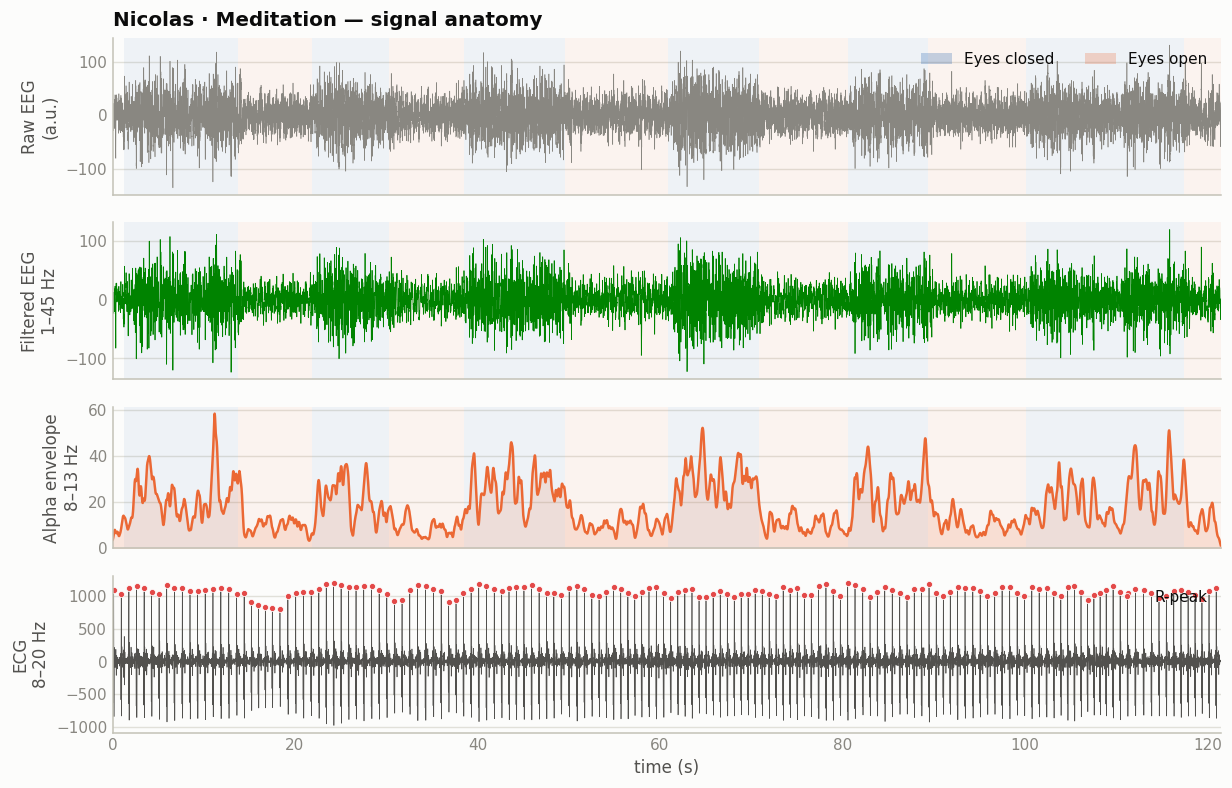

In [ ]:
def find_rec(subject, condition):
    row = manifest[(manifest.subject==subject)&(manifest.condition==condition)].iloc[0]
    fs, eeg_raw, ecg_raw = load_signals(row["wav"])
    return fs, eeg_raw, ecg_raw, load_events(row["events"])

SUBJ, COND = "Nicolas", "meditation"
fs, eeg_raw, ecg_raw, ev = find_rec(SUBJ, COND)
eeg = preprocess_eeg(eeg_raw, fs)
ecg = sosfiltfilt(butter(3,[8,20],"band",fs=fs,output="sos"), ecg_raw-ecg_raw.mean())
env = alpha_envelope(eeg, fs); peaks = detect_rpeaks(ecg_raw, fs)
t = np.arange(len(eeg))/fs
segs = epochs_from_events(ev, len(eeg), fs)

fig, axs = plt.subplots(4, 1, figsize=(13, 8.2), sharex=True,
                        gridspec_kw=dict(hspace=0.18, height_ratios=[1,1,0.9,1]))
def shade(ax):
    for (s,e,st) in segs:
        if st in C_STATE: ax.axvspan(s, e, color=C_STATE[st], alpha=0.06, lw=0)

ax=axs[0]; shade(ax); ax.plot(t, eeg_raw-eeg_raw.mean(), color=MUTED, lw=0.4)
ax.set_ylabel("Raw EEG\n(a.u.)"); style(ax,"y")
ax.set_title(f"{SUBJ} · {COND_EN[COND]} — signal anatomy", loc="left", pad=8)
ax=axs[1]; shade(ax); ax.plot(t, eeg, color=C_COND[COND], lw=0.5)
ax.set_ylabel("Filtered EEG\n1–45 Hz"); style(ax,"y")
ax=axs[2]; shade(ax); ax.plot(t, env, color=C_ALPHA, lw=1.6)
ax.fill_between(t, 0, env, color=C_ALPHA, alpha=0.15)
ax.set_ylabel("Alpha envelope\n8–13 Hz"); style(ax,"y"); ax.set_ylim(0,None)
ax=axs[3]; ax.plot(t, ecg, color=INK2, lw=0.45)
ax.plot(peaks/fs, ecg[peaks], "o", ms=4, color=C_COND["stress"], mec="white", mew=0.5, label="R-peak")
ax.set_ylabel("ECG\n8–20 Hz"); ax.set_xlabel("time (s)"); style(ax,"y"); ax.legend(loc="upper right")
ax.set_xlim(0, t[-1])
leg = [Patch(facecolor=C_STATE["closed"], alpha=0.25, label="Eyes closed"),
       Patch(facecolor=C_STATE["open"], alpha=0.25, label="Eyes open")]
axs[0].legend(handles=leg, loc="upper right", ncol=2)
plt.show()


## 5 · The Berger effect

Hans Berger's classic finding (1929): when the **eyes close**, power in the **alpha band (8–12 Hz)** increases. We compare the average spectrum (Welch, 0.5 Hz resolution) of all closed epochs vs open epochs, pooled across the 7 subjects.

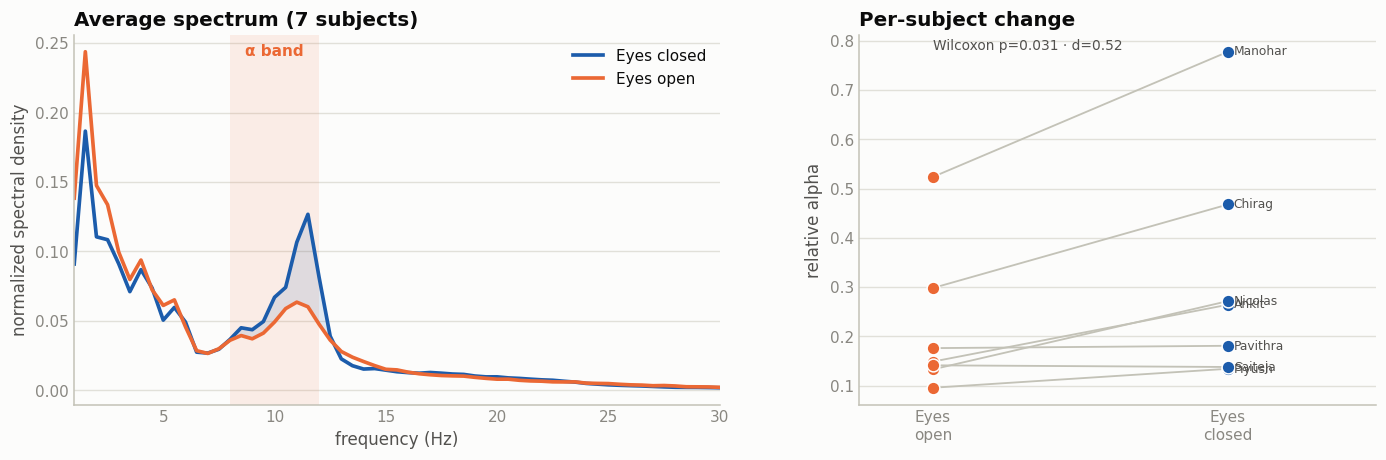

In [ ]:
def avg_psd(mask, band=(1,30)):
    acc = None; nf = 0; fsel = None
    for _, r in manifest.iterrows():
        fs, eeg_raw, _ = load_signals(r["wav"]); eeg = preprocess_eeg(eeg_raw, fs)
        ev = load_events(r["events"])
        for (s,e,st) in epochs_from_events(ev, len(eeg), fs):
            if st != mask: continue
            seg = eeg[int(s*fs):int(e*fs)]
            if len(seg) < fs: continue
            f, p = welch(seg, fs, nperseg=int(fs*2))
            sel = (f>=band[0])&(f<=band[1]); fsel = f[sel]
            p = p[sel]/np.trapz(p[(f>=1)&(f<45)], f[(f>=1)&(f<45)])
            acc = p if acc is None else acc+p; nf += 1
    return fsel, acc/nf

fA, pClosed = avg_psd("closed"); _, pOpen = avg_psd("open")

fig = plt.figure(figsize=(13, 4.8))
gs = GridSpec(1, 2, width_ratios=[1.25,1], wspace=0.24, left=0.07, right=0.98, top=0.86, bottom=0.16)
ax = fig.add_subplot(gs[0])
ax.axvspan(8, 12, color=C_ALPHA, alpha=0.10, lw=0)
ax.plot(fA, pClosed, color=C_STATE["closed"], lw=2.4, label="Eyes closed")
ax.plot(fA, pOpen, color=C_STATE["open"], lw=2.4, label="Eyes open")
ax.fill_between(fA, pOpen, pClosed, where=(pClosed>=pOpen), color=C_STATE["closed"], alpha=0.12)
style(ax); ax.set_xlim(1,30); ax.set_xlabel("frequency (Hz)"); ax.set_ylabel("normalized spectral density")
ax.set_title("Average spectrum (7 subjects)", loc="left")
ax.text(10, ax.get_ylim()[1]*0.94, "α band", color=C_ALPHA, fontweight="bold", ha="center", fontsize=10)
ax.legend(loc="upper right")

ax2 = fig.add_subplot(gs[1])
piv = ep_state.pivot_table(index="subject", columns="state", values="Alpha_rel", aggfunc="mean")
subs = piv.index.tolist()
for s in subs:
    ax2.plot([0,1], [piv.loc[s,"open"], piv.loc[s,"closed"]], "-", color=AXIS, lw=1.2, zorder=1)
ax2.scatter([0]*len(subs), piv["open"], s=70, color=C_STATE["open"], zorder=3, ec="white", lw=1)
ax2.scatter([1]*len(subs), piv["closed"], s=70, color=C_STATE["closed"], zorder=3, ec="white", lw=1)
for s in subs:
    ax2.annotate(s, (1.02, piv.loc[s,"closed"]), fontsize=8, color=INK2, va="center")
ax2.set_xticks([0,1]); ax2.set_xticklabels(["Eyes\nopen","Eyes\nclosed"]); ax2.set_xlim(-0.25,1.5)
style(ax2); ax2.set_ylabel("relative alpha"); ax2.set_title("Per-subject change", loc="left")
d = cohend(piv["closed"], piv["open"]); w = stats.wilcoxon(piv["closed"], piv["open"])
ax2.text(0.0, ax2.get_ylim()[1]*0.99, f"Wilcoxon p={w.pvalue:.3f} · d={d:.2f}", fontsize=9, color=INK2, va="top")
plt.show()


### Relative power by band

Is the increase specific to alpha, or does it affect the whole spectrum? We compare the 5 classic bands between eyes closed and open (**relative** power, averaged over all epochs). The expected signature is a **selective alpha increase**.

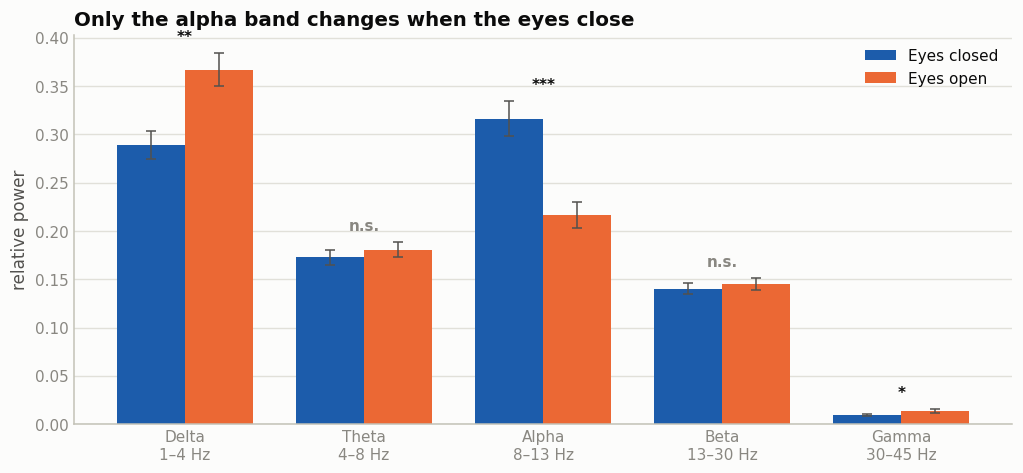

In [ ]:
bands = list(BANDS.keys())
fig, ax = plt.subplots(figsize=(11, 4.6))
x = np.arange(len(bands)); w = 0.38
means = {st: [ep_state[ep_state.state==st][f"{b}_rel"].mean() for b in bands] for st in ["closed","open"]}
sems  = {st: [ep_state[ep_state.state==st][f"{b}_rel"].sem()  for b in bands] for st in ["closed","open"]}
ax.bar(x-w/2, means["closed"], w, yerr=sems["closed"], color=C_STATE["closed"], label="Eyes closed",
       capsize=3, error_kw=dict(lw=1, ecolor=INK2))
ax.bar(x+w/2, means["open"], w, yerr=sems["open"], color=C_STATE["open"], label="Eyes open",
       capsize=3, error_kw=dict(lw=1, ecolor=INK2))
for i,b in enumerate(bands):
    a = ep_state[ep_state.state=="closed"][f"{b}_rel"].dropna()
    o = ep_state[ep_state.state=="open"][f"{b}_rel"].dropna()
    p = stats.mannwhitneyu(a,o).pvalue
    star = "***" if p<1e-3 else "**" if p<1e-2 else "*" if p<0.05 else "n.s."
    yy = max(means["closed"][i],means["open"][i]) + max(sems["closed"][i],sems["open"][i]) + 0.012
    ax.text(i, yy, star, ha="center", color=INK if p<0.05 else MUTED, fontsize=10, fontweight="bold")
ax.set_xticks(x); ax.set_xticklabels([f"{b}\n{BANDS[b][0]}–{BANDS[b][1]} Hz" for b in bands])
style(ax); ax.set_ylabel("relative power"); ax.legend(loc="upper right")
ax.set_title("Only the alpha band changes when the eyes close", loc="left")
plt.show()


## 6 · 🎼 Music and the alpha rhythm

For each subject we average the relative alpha of their **eyes-closed** epochs (the state that best reveals relaxation) in each condition. Lines connect each subject across the 4 conditions; the **Friedman test** evaluates the global effect of music.

> **Read this honestly:** the *ordering* is consistent — meditation music yields the most alpha and stress the least — but with n = 7 and large between-person variability the effect is a **descriptive trend, not statistically significant** (see the Friedman p-value on the plot). It is a hypothesis worth a larger study, not a proven effect.

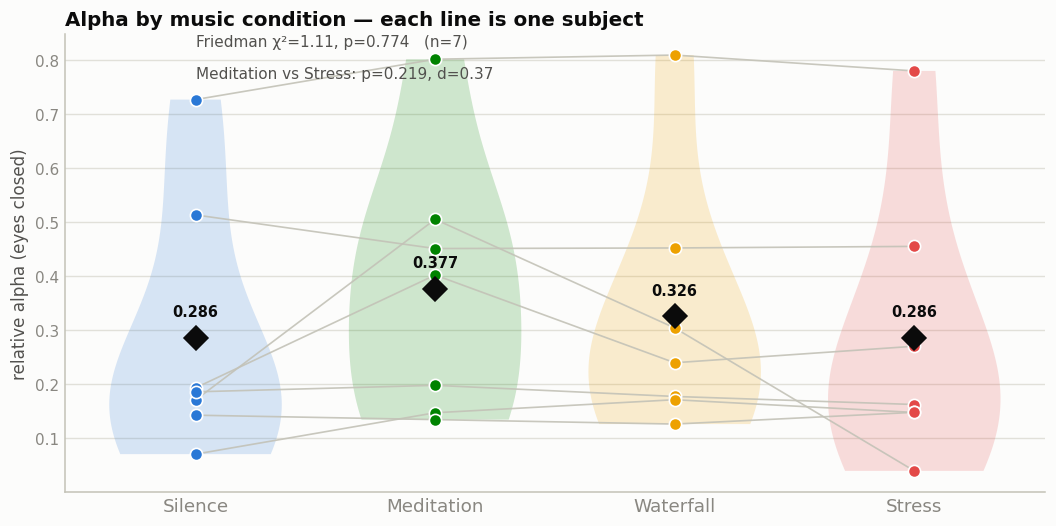

In [ ]:
cc = ep_state[ep_state.state=="closed"]
pv = cc.pivot_table(index="subject", columns="condition", values="Alpha_rel",
                    aggfunc="mean", observed=False)[CONDITIONS]

fig, ax = plt.subplots(figsize=(11.5, 5.4))
xpos = np.arange(4)
parts = ax.violinplot([pv[c].dropna().values for c in CONDITIONS], positions=xpos,
                      widths=0.72, showextrema=False)
for i,b in enumerate(parts["bodies"]):
    b.set_facecolor(C_COND[CONDITIONS[i]]); b.set_alpha(0.18); b.set_edgecolor("none")
for s in pv.index:
    ax.plot(xpos, pv.loc[s].values, "-", color=AXIS, lw=1.1, zorder=2, alpha=0.9)
for i,c in enumerate(CONDITIONS):
    ax.scatter([i]*len(pv), pv[c].values, s=64, color=C_COND[c], ec="white", lw=1.1, zorder=3)
mrs = pv.mean()
ax.plot(xpos, mrs.values, "D", ms=11, color=INK, zorder=4)
for i,c in enumerate(CONDITIONS):
    ax.annotate(f"{mrs[c]:.3f}", (i, mrs[c]), textcoords="offset points", xytext=(0,14),
                ha="center", fontsize=9.5, fontweight="bold", color=INK)
ax.set_xticks(xpos); ax.set_xticklabels([COND_EN[c] for c in CONDITIONS], fontsize=12)
style(ax); ax.set_ylabel("relative alpha (eyes closed)")
fr = stats.friedmanchisquare(*[pv[c].values for c in CONDITIONS])
ax.set_title("Alpha by music condition — each line is one subject", loc="left")
ax.text(0.0, ax.get_ylim()[1], f"Friedman χ²={fr.statistic:.2f}, p={fr.pvalue:.3f}   (n=7)",
        fontsize=10, color=INK2, va="top")
wm = stats.wilcoxon(pv["meditation"], pv["stress"])
ax.text(0.0, ax.get_ylim()[1]*0.93,
        f"Meditation vs Stress: p={wm.pvalue:.3f}, d={cohend(pv['meditation'],pv['stress']):.2f}",
        fontsize=10, color=INK2, va="top")
plt.show()


### Spectrogram gallery

The same person across the 4 conditions. The vertical axis is frequency (0–30 Hz), color is energy. The alpha strip (8–12 Hz) is highlighted; the ribbon on top marks eyes closed (blue) / open (orange). Brighter horizontal bands in alpha appear during closed blocks.

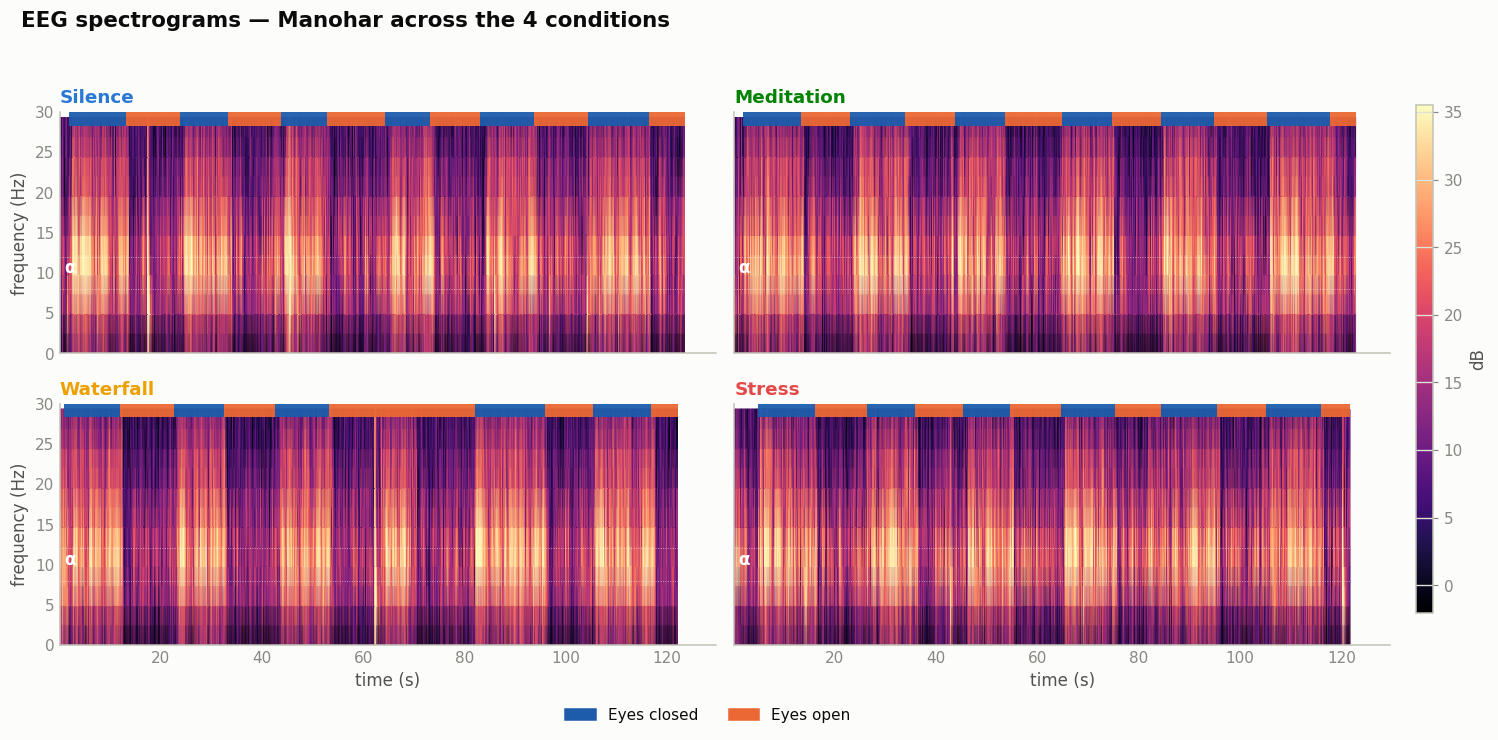

In [ ]:
GSUB = "Manohar"
fig, axs = plt.subplots(2, 2, figsize=(13, 6.6), sharex=True, sharey=True)
axs = axs.ravel()
for k, c in enumerate(CONDITIONS):
    fs, eeg_raw, _, ev = find_rec(GSUB, c)
    eeg = preprocess_eeg(eeg_raw, fs)
    f, tt, Sxx = spectrogram(eeg, fs, nperseg=1024, noverlap=896)
    sel = f <= 30
    S = 10*np.log10(Sxx[sel]+1e-12)
    ax = axs[k]
    pcm = ax.pcolormesh(tt, f[sel], S, cmap="magma", shading="gouraud",
                        vmin=np.percentile(S,5), vmax=np.percentile(S,99))
    ax.axhline(8, color="white", lw=0.6, ls=":", alpha=0.6); ax.axhline(12, color="white", lw=0.6, ls=":", alpha=0.6)
    for (s,e,st) in epochs_from_events(ev, len(eeg), fs):
        if st in C_STATE:
            ax.add_patch(plt.Rectangle((s,28.3),e-s,1.7,color=C_STATE[st],lw=0,alpha=0.95,clip_on=False))
    ax.set_title(COND_EN[c], loc="left", color=C_COND[c], fontsize=12)
    ax.set_ylim(0,30); ax.grid(False); ax.tick_params(length=0)
    for sp in ax.spines.values(): sp.set_color(AXIS)
    if k in (2,3): ax.set_xlabel("time (s)")
    if k in (0,2): ax.set_ylabel("frequency (Hz)")
    ax.text(1, 10, "α", color="white", fontweight="bold", fontsize=11)
fig.suptitle(f"EEG spectrograms — {GSUB} across the 4 conditions", x=0.02, ha="left",
             fontsize=14, fontweight="bold")
cax = fig.add_axes([0.995, 0.15, 0.012, 0.7]); fig.colorbar(pcm, cax=cax, label="dB")
leg = [Patch(color=C_STATE["closed"], label="Eyes closed"), Patch(color=C_STATE["open"], label="Eyes open")]
fig.legend(handles=leg, loc="lower center", ncol=2, bbox_to_anchor=(0.5,-0.02))
plt.tight_layout(rect=[0,0.02,0.99,0.95]); plt.show()


## 7 · 💓 The heart and music

Using the robust autocorrelation heart rate on **good-quality ECG recordings only**, we compare mean heart rate across conditions. Lines connect each subject; the black diamond is the group mean. The right panel shows each subject's change relative to their own silent baseline.

> Again read as a **trend**: stress music tends to raise heart rate the most, but the Friedman test is not significant at n = 5 clean subjects.

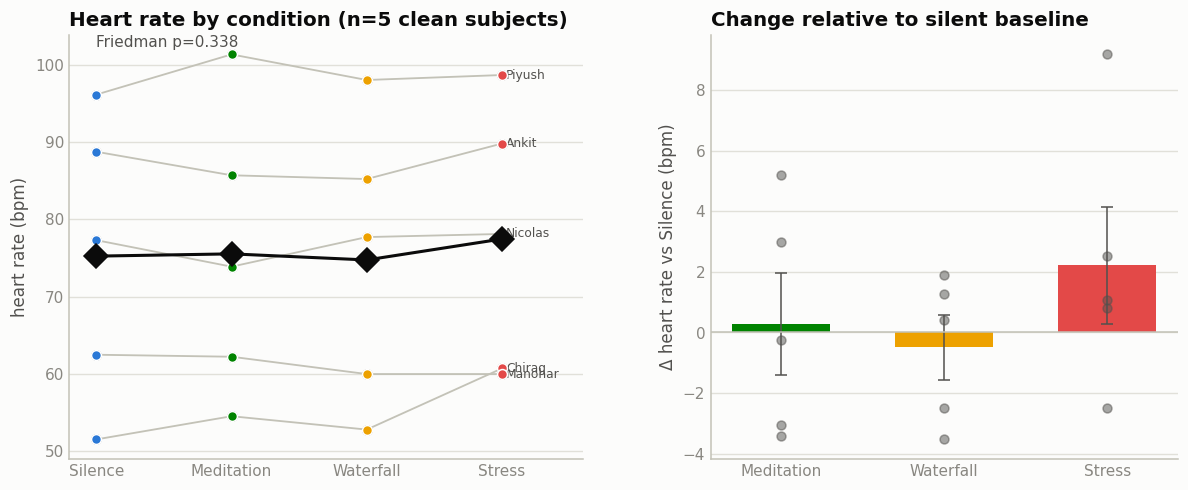

In [ ]:
good = rec[rec.ecg_ok].copy()
hr_pv = good.pivot_table(index="subject", columns="condition", values="hr", observed=False)[CONDITIONS]
hr_pv = hr_pv.dropna(how="any")          # subjects with all 4 conditions of good quality

fig, axs = plt.subplots(1, 2, figsize=(13, 5.0), gridspec_kw=dict(width_ratios=[1.1,1], wspace=0.26))
ax = axs[0]; xpos = np.arange(4)
for s in hr_pv.index:
    ax.plot(xpos, hr_pv.loc[s].values, "-o", color=AXIS, mfc="white", mec=INK2, ms=6, lw=1.2, zorder=2)
    ax.annotate(s, (3.03, hr_pv.loc[s,"stress"]), fontsize=8, color=INK2, va="center")
mrs = hr_pv.mean()
ax.plot(xpos, mrs.values, "D-", ms=11, color=INK, lw=2, zorder=4)
for i,c in enumerate(CONDITIONS):
    ax.scatter([i]*len(hr_pv), hr_pv[c].values, s=42, color=C_COND[c], ec="white", lw=1, zorder=3)
ax.set_xticks(xpos); ax.set_xticklabels([COND_EN[c] for c in CONDITIONS]); ax.set_xlim(-0.2,3.6)
style(ax); ax.set_ylabel("heart rate (bpm)")
fr = stats.friedmanchisquare(*[hr_pv[c].values for c in CONDITIONS])
ax.set_title(f"Heart rate by condition (n={len(hr_pv)} clean subjects)", loc="left")
ax.text(0.0, ax.get_ylim()[1], f"Friedman p={fr.pvalue:.3f}", fontsize=10, color=INK2, va="top")

# within-subject change vs silence baseline
ax2 = axs[1]
delta = hr_pv.sub(hr_pv["nomusic"], axis=0)[["meditation","waterfall","stress"]]
xb = np.arange(3)
mb = delta.mean(); sb = delta.sem()
bcol = [C_COND[c] for c in ["meditation","waterfall","stress"]]
ax2.bar(xb, mb.values, 0.6, yerr=sb.values, color=bcol, capsize=4, error_kw=dict(lw=1,ecolor=INK2))
for i,c in enumerate(["meditation","waterfall","stress"]):
    ax2.scatter([i]*len(delta), delta[c].values, s=34, color=INK2, alpha=0.5, zorder=3)
ax2.axhline(0, color=AXIS, lw=1)
ax2.set_xticks(xb); ax2.set_xticklabels([COND_EN[c] for c in ["meditation","waterfall","stress"]])
style(ax2); ax2.set_ylabel("Δ heart rate vs Silence (bpm)")
ax2.set_title("Change relative to silent baseline", loc="left")
plt.show()


### Heart-rate variability — Poincaré plots

Each point plots one RR interval against the next (RRₙ vs RRₙ₊₁). A **tight cloud** = low variability (higher arousal); a **spread cloud** = high variability (relaxed, healthy vagal tone). Shown for one clean subject across conditions, with the RMSSD summary alongside.

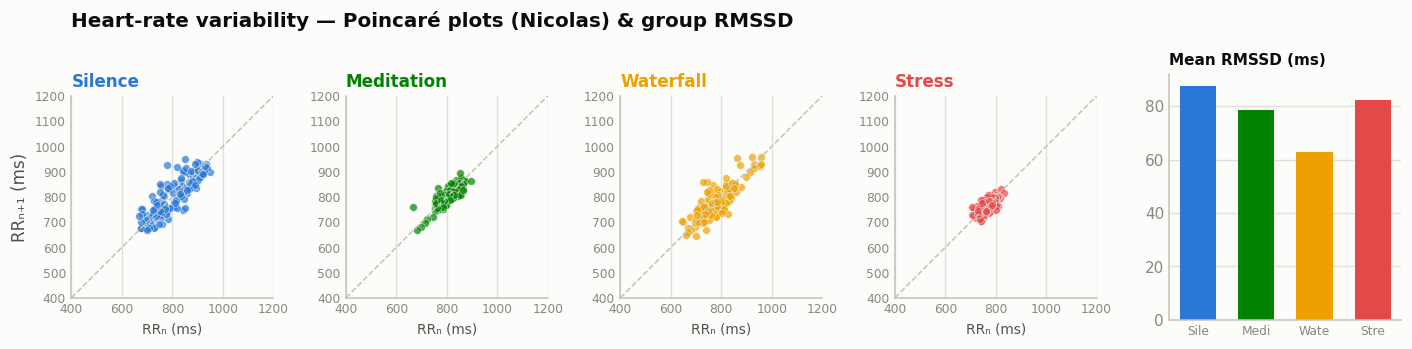

In [ ]:
PSUB = "Nicolas"
fig = plt.figure(figsize=(13, 3.6))
gs = GridSpec(1, 5, width_ratios=[1,1,1,1,1.15], wspace=0.35, left=0.05, right=0.98, bottom=0.2, top=0.82)
lims = [400, 1200]
for k,c in enumerate(CONDITIONS):
    fs, _, ecg_raw, _ = find_rec(PSUB, c)
    rr = clean_rr(detect_rpeaks(ecg_raw, fs), fs)
    ax = fig.add_subplot(gs[k])
    if len(rr) > 2:
        ax.scatter(rr[:-1], rr[1:], s=26, color=C_COND[c], alpha=0.7, ec="white", lw=0.4)
    ax.plot(lims, lims, color=AXIS, lw=1, ls="--")
    ax.set_xlim(lims); ax.set_ylim(lims); ax.set_aspect("equal")
    ax.set_title(COND_EN[c], color=C_COND[c], fontsize=11, loc="left")
    style(ax, grid_axis="both"); ax.tick_params(labelsize=8)
    if k==0: ax.set_ylabel("RRₙ₊₁ (ms)")
    ax.set_xlabel("RRₙ (ms)", fontsize=9)

axr = fig.add_subplot(gs[4])
rm = good.pivot_table(index="subject", columns="condition", values="rmssd", observed=False)[CONDITIONS].mean()
axr.bar(range(4), rm.values, 0.62, color=[C_COND[c] for c in CONDITIONS])
axr.set_xticks(range(4)); axr.set_xticklabels([COND_EN[c][:4] for c in CONDITIONS], fontsize=8)
style(axr); axr.set_title("Mean RMSSD (ms)", fontsize=10, loc="left")
fig.suptitle(f"Heart-rate variability — Poincaré plots ({PSUB}) & group RMSSD", x=0.05, ha="left",
             fontsize=13, fontweight="bold")
plt.show()


## 8 · 🧠💓 The brain–heart axis

Do relaxed brains (more alpha) go with slower hearts? Because subjects differ hugely in baseline alpha and heart rate, we **z-score within each subject** so the coupling is not driven by between-person differences. Each point is one recording, colored by condition.

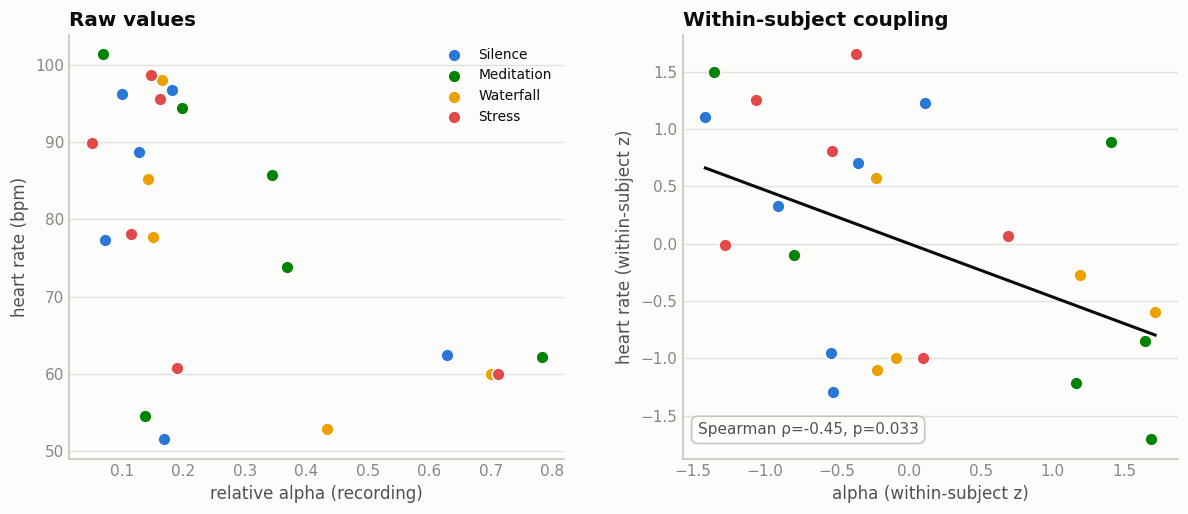

In [ ]:
bh = rec[rec.ecg_ok].dropna(subset=["hr","alpha_rel"]).copy()
# within-subject z-scores
def zc(g, col):
    v = g[col]; return (v - v.mean())/v.std(ddof=0) if v.std(ddof=0)>0 else v*0
bh["alpha_z"] = bh.groupby("subject", observed=False).apply(lambda g: zc(g,"alpha_rel")).reset_index(level=0, drop=True)
bh["hr_z"]    = bh.groupby("subject", observed=False).apply(lambda g: zc(g,"hr")).reset_index(level=0, drop=True)

fig, axs = plt.subplots(1, 2, figsize=(13, 5.0), gridspec_kw=dict(width_ratios=[1,1], wspace=0.24))
# raw
ax = axs[0]
for c in CONDITIONS:
    d = bh[bh.condition==c]
    ax.scatter(d["alpha_rel"], d["hr"], s=70, color=C_COND[c], ec="white", lw=1, label=COND_EN[c])
style(ax); ax.set_xlabel("relative alpha (recording)"); ax.set_ylabel("heart rate (bpm)")
ax.set_title("Raw values", loc="left"); ax.legend(loc="upper right", fontsize=9)

# within-subject z
ax2 = axs[1]
for c in CONDITIONS:
    d = bh[bh.condition==c]
    ax2.scatter(d["alpha_z"], d["hr_z"], s=70, color=C_COND[c], ec="white", lw=1, label=COND_EN[c])
x = bh["alpha_z"].values; yv = bh["hr_z"].values
m,b = np.polyfit(x, yv, 1); xs = np.linspace(x.min(), x.max(), 50)
ax2.plot(xs, m*xs+b, color=INK, lw=2, zorder=1)
r, p = stats.spearmanr(x, yv)
style(ax2); ax2.set_xlabel("alpha (within-subject z)"); ax2.set_ylabel("heart rate (within-subject z)")
ax2.set_title("Within-subject coupling", loc="left")
ax2.text(0.03, 0.05, f"Spearman ρ={r:.2f}, p={p:.3f}", transform=ax2.transAxes,
         fontsize=10, color=INK2, va="bottom",
         bbox=dict(boxstyle="round,pad=0.4", fc="white", ec=AXIS, lw=1))
plt.show()


### Per-subject view — every epoch in the alpha–heart plane

The most direct way to ask *"does eye state change the brain and the heart differently?"*: plot **one point per epoch**, alpha on x and heart rate on y, split by eyes closed vs open. The large diamonds are the per-state means. A **horizontal gap** between them means alpha moved with eye state; a **vertical gap** means heart rate moved. The 8th panel summarizes each subject as Δ(closed − open).

The pattern is consistent: eye closure shifts the cloud **rightward (more alpha)** but barely up or down — **heart rate is largely unchanged by eye state**. (The two low-quality-ECG subjects show a spurious vertical shift and are flagged.)

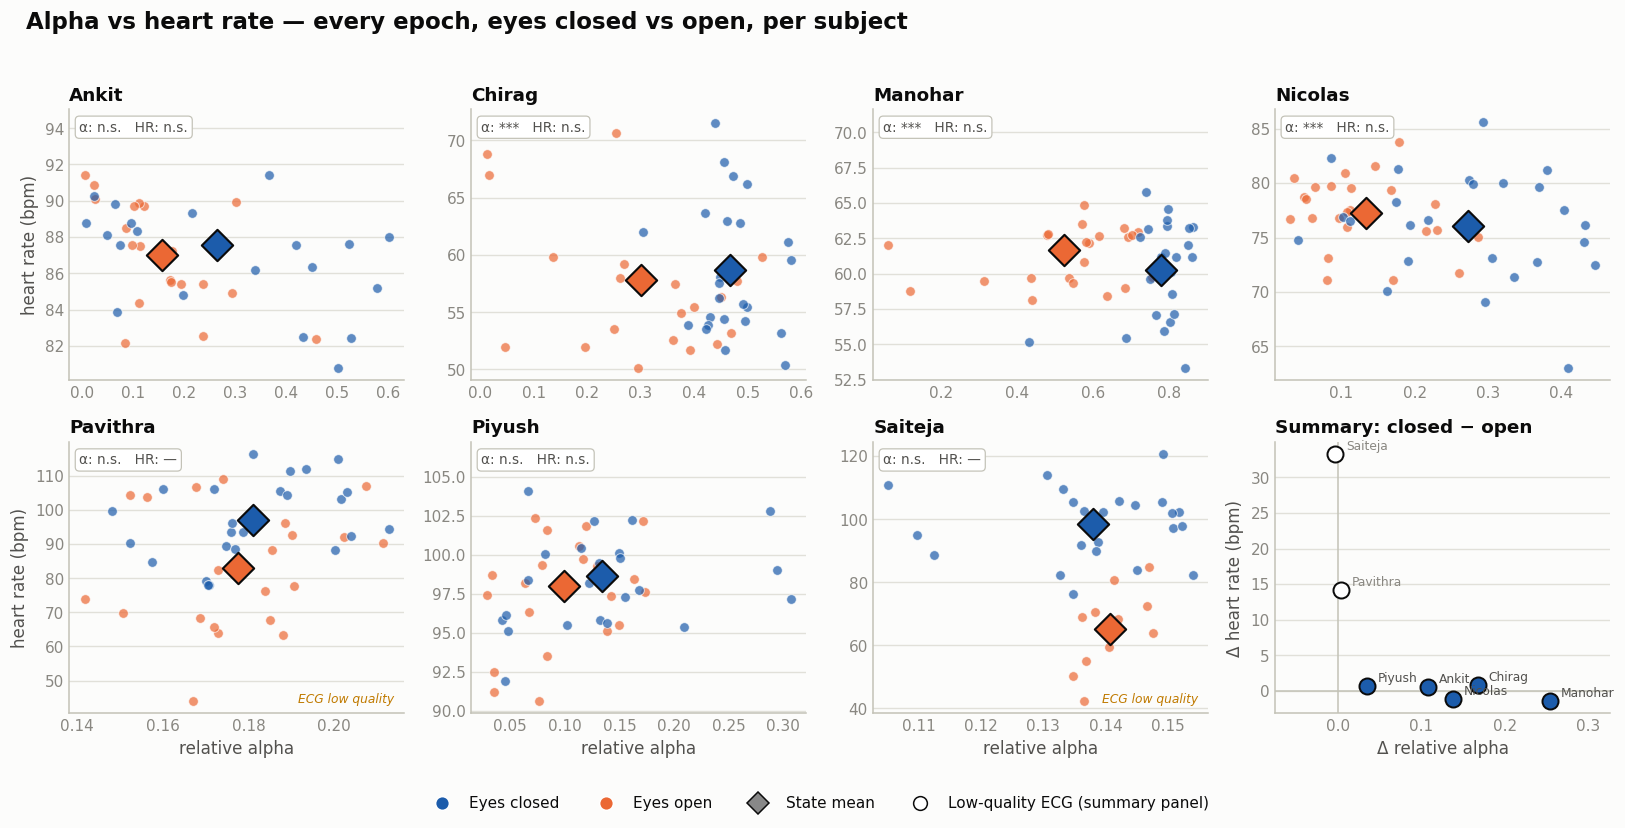

In [ ]:
from matplotlib.lines import Line2D
BAD = set(rec.groupby("subject")["ecg_ok"].mean().pipe(lambda s: s[s < 1.0].index))
subs = sorted(ep_state.subject.unique())
dd_all = ep_state.dropna(subset=["hr","Alpha_rel"])
star = lambda p: "***" if p<1e-3 else "**" if p<1e-2 else "*" if p<0.05 else "n.s."

fig, axs = plt.subplots(2, 4, figsize=(15, 7.4)); axs = axs.ravel()
summary = []
for k, s in enumerate(subs):
    ax = axs[k]; d = dd_all[dd_all.subject == s]
    for st in ("open","closed"):
        g = d[d.state == st]
        ax.scatter(g["Alpha_rel"], g["hr"], s=40, color=C_STATE[st], alpha=0.70, ec="white", lw=0.6, zorder=2)
        if len(g):
            ax.scatter(g["Alpha_rel"].mean(), g["hr"].mean(), s=210, marker="D",
                       color=C_STATE[st], ec=INK, lw=1.4, zorder=4)
    ac, ao = d[d.state=="closed"]["Alpha_rel"], d[d.state=="open"]["Alpha_rel"]
    hc, ho = d[d.state=="closed"]["hr"], d[d.state=="open"]["hr"]
    pa = stats.mannwhitneyu(ac, ao).pvalue; ph = stats.mannwhitneyu(hc, ho).pvalue
    summary.append(dict(subject=s, da=ac.mean()-ao.mean(), dh=hc.mean()-ho.mean(), bad=s in BAD))
    style(ax); ax.set_title(s, loc="left", fontweight="bold", fontsize=12, pad=6)
    ax.text(0.03, 0.96, f"α: {star(pa)}   HR: {'—' if s in BAD else star(ph)}",
            transform=ax.transAxes, va="top", fontsize=9, color=INK2,
            bbox=dict(boxstyle="round,pad=0.3", fc="white", ec=AXIS, lw=0.8))
    if s in BAD:
        ax.text(0.97, 0.04, "ECG low quality", transform=ax.transAxes, ha="right",
                fontsize=8, color="#c07a00", style="italic")
    if k >= 4: ax.set_xlabel("relative alpha")
    if k % 4 == 0: ax.set_ylabel("heart rate (bpm)")

sm = pd.DataFrame(summary); ax = axs[7]
ax.axhline(0, color=AXIS, lw=1); ax.axvline(0, color=AXIS, lw=1)
for _, r in sm.iterrows():
    ax.scatter(r["da"], r["dh"], s=110, color=("white" if r["bad"] else C_STATE["closed"]),
               ec=INK, lw=1.3, zorder=3)
    ax.annotate(r["subject"], (r["da"], r["dh"]), textcoords="offset points", xytext=(7,3),
                fontsize=8, color=(MUTED if r["bad"] else INK2))
style(ax); ax.margins(x=0.28)
ax.set_title("Summary: closed − open", loc="left", fontweight="bold", fontsize=12, pad=6)
ax.set_xlabel("Δ relative alpha"); ax.set_ylabel("Δ heart rate (bpm)")

h = [Line2D([0],[0],marker="o",ls="",mfc=C_STATE["closed"],mec="white",ms=9,label="Eyes closed"),
     Line2D([0],[0],marker="o",ls="",mfc=C_STATE["open"],mec="white",ms=9,label="Eyes open"),
     Line2D([0],[0],marker="D",ls="",mfc="#888",mec=INK,ms=10,label="State mean"),
     Line2D([0],[0],marker="o",ls="",mfc="white",mec=INK,ms=9,label="Low-quality ECG (summary panel)")]
fig.legend(handles=h, loc="lower center", ncol=4, fontsize=10, frameon=False, bbox_to_anchor=(0.5,-0.02))
fig.suptitle("Alpha vs heart rate — every epoch, eyes closed vs open, per subject",
             x=0.02, ha="left", fontsize=15, fontweight="bold")
plt.tight_layout(rect=[0,0.04,1,0.96]); plt.show()


## 9 · Machine learning — decoding eyes closed vs open

Can a model tell eyes-closed from eyes-open epochs using EEG band features? The honest test is **leave-one-subject-out** (train on 6 subjects, test on the 7th) — a random split would leak subject identity and inflate accuracy. We report both to expose the gap.

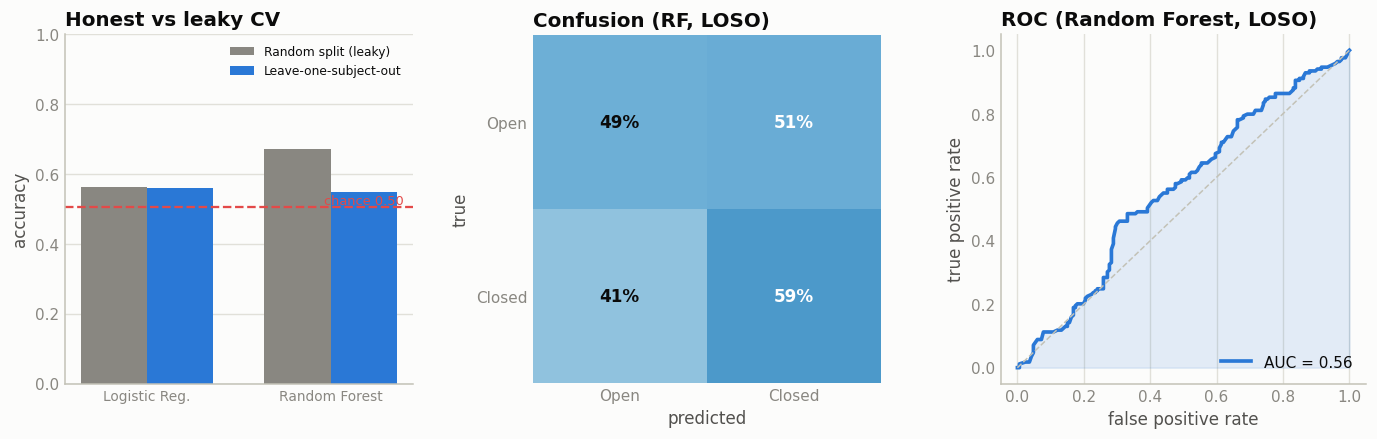

Accuracy summary: {'Logistic Reg.': (0.564, 0.561), 'Random Forest': (0.672, 0.549)} · chance 0.504


In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import cross_val_predict, StratifiedKFold, LeaveOneGroupOut
from sklearn.metrics import confusion_matrix, roc_curve, auc, accuracy_score

feat_cols = [f"{b}_rel" for b in BANDS] + list(BANDS.keys())
d = ep_state.dropna(subset=feat_cols).copy()
X = d[feat_cols].values
y = (d["state"]=="closed").astype(int).values
groups = d["subject"].values

logo = LeaveOneGroupOut()
skf  = StratifiedKFold(5, shuffle=True, random_state=0)
rf   = lambda: RandomForestClassifier(300, random_state=0)
lr   = lambda: make_pipeline(StandardScaler(), LogisticRegression(max_iter=1000))

res = {}
for name, mk in [("Logistic Reg.", lr), ("Random Forest", rf)]:
    acc_leak = accuracy_score(y, cross_val_predict(mk(), X, y, cv=skf))
    acc_honest = accuracy_score(y, cross_val_predict(mk(), X, y, cv=logo, groups=groups))
    res[name] = (acc_leak, acc_honest)
chance = max(np.mean(y), 1-np.mean(y))
proba = cross_val_predict(rf(), X, y, cv=logo, groups=groups, method="predict_proba")[:,1]
pred  = (proba>=0.5).astype(int)

fig = plt.figure(figsize=(13, 4.6))
gs = GridSpec(1, 3, width_ratios=[1,1,1.05], wspace=0.34, left=0.06, right=0.97, top=0.85, bottom=0.16)

# accuracy bars
ax = fig.add_subplot(gs[0]); names=list(res); xb=np.arange(len(names)); w=0.36
ax.bar(xb-w/2, [res[n][0] for n in names], w, color=MUTED, label="Random split (leaky)")
ax.bar(xb+w/2, [res[n][1] for n in names], w, color=C_COND["nomusic"], label="Leave-one-subject-out")
ax.axhline(chance, color=C_COND["stress"], ls="--", lw=1.5)
ax.text(1.4, chance+0.01, f"chance {chance:.2f}", color=C_COND["stress"], fontsize=8.5, ha="right")
ax.set_xticks(xb); ax.set_xticklabels(names, fontsize=9); ax.set_ylim(0,1)
style(ax); ax.set_ylabel("accuracy"); ax.legend(fontsize=8); ax.set_title("Honest vs leaky CV", loc="left")

# confusion matrix
ax2 = fig.add_subplot(gs[1]); cm = confusion_matrix(y, pred, normalize="true")
im = ax2.imshow(cm, cmap="Blues", vmin=0, vmax=1)
for i in range(2):
    for j in range(2):
        ax2.text(j,i,f"{cm[i,j]:.0%}",ha="center",va="center",
                 color="white" if cm[i,j]>0.5 else INK, fontweight="bold")
ax2.set_xticks([0,1]); ax2.set_xticklabels(["Open","Closed"]); ax2.set_yticks([0,1]); ax2.set_yticklabels(["Open","Closed"])
ax2.set_xlabel("predicted"); ax2.set_ylabel("true"); ax2.grid(False); ax2.tick_params(length=0)
ax2.set_title(f"Confusion (RF, LOSO)", loc="left")
for sp in ax2.spines.values(): sp.set_visible(False)

# ROC
ax3 = fig.add_subplot(gs[2]); fpr,tpr,_ = roc_curve(y, proba); A=auc(fpr,tpr)
ax3.plot(fpr,tpr,color=C_COND["nomusic"],lw=2.4,label=f"AUC = {A:.2f}")
ax3.plot([0,1],[0,1],color=AXIS,ls="--",lw=1)
ax3.fill_between(fpr,tpr,color=C_COND["nomusic"],alpha=0.12)
style(ax3, grid_axis="both"); ax3.set_xlabel("false positive rate"); ax3.set_ylabel("true positive rate")
ax3.set_title("ROC (Random Forest, LOSO)", loc="left"); ax3.legend(loc="lower right")
plt.show()
print("Accuracy summary:", {k:(round(a,3),round(b,3)) for k,(a,b) in res.items()}, "· chance", round(chance,3))


## 10 · Summary dashboard

The whole study in one frame: the four headline numbers and the key comparisons.

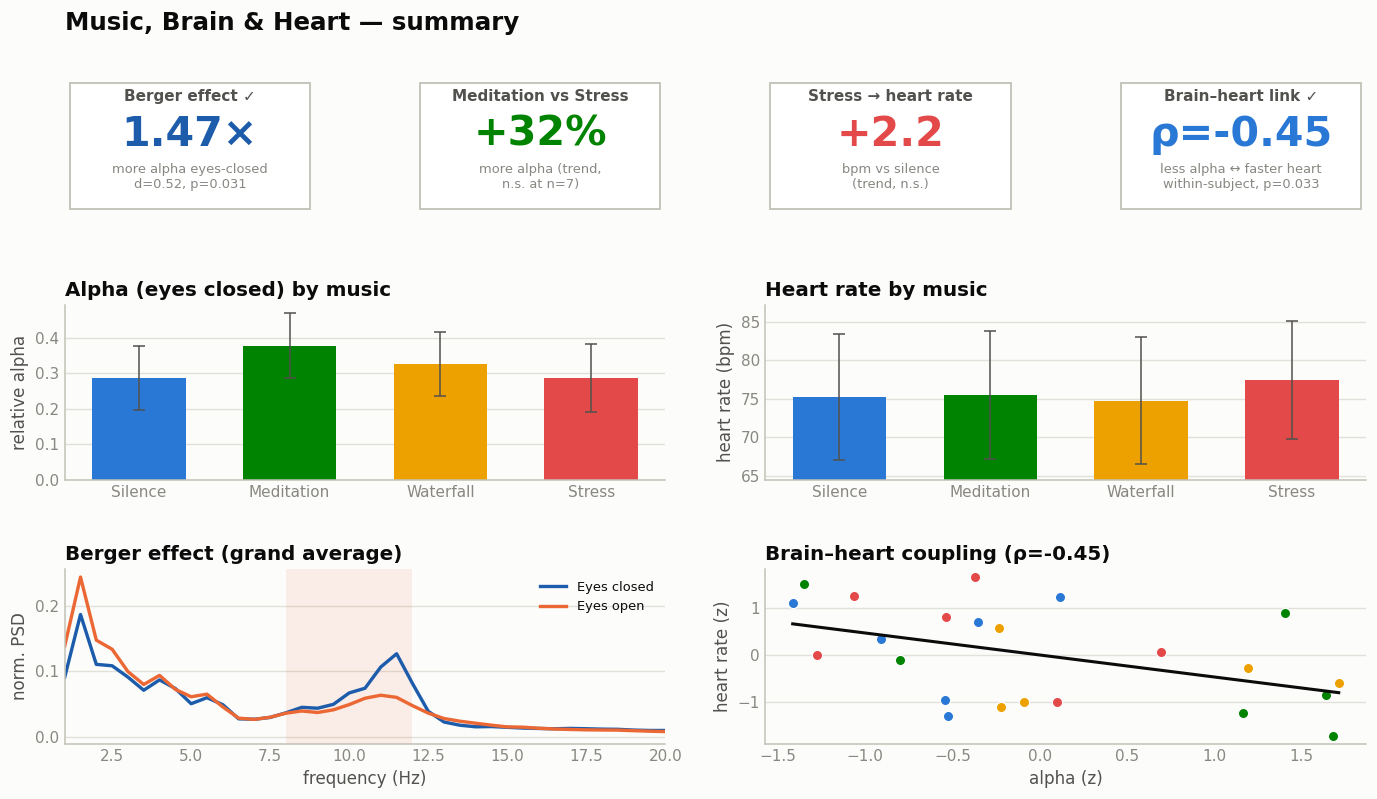

In [ ]:
# gather headline metrics
piv_state = ep_state.pivot_table(index="subject", columns="state", values="Alpha_rel", aggfunc="mean")
berger_d = cohend(piv_state["closed"], piv_state["open"])
berger_ratio = piv_state["closed"].mean()/piv_state["open"].mean()
pv_c = ep_state[ep_state.state=="closed"].pivot_table(index="subject", columns="condition",
        values="Alpha_rel", aggfunc="mean", observed=False)[CONDITIONS]
med_vs_stress = (pv_c["meditation"].mean()-pv_c["stress"].mean())/pv_c["stress"].mean()*100
hr_good = rec[rec.ecg_ok].pivot_table(index="subject", columns="condition", values="hr", observed=False)[CONDITIONS].dropna()
hr_stress_delta = (hr_good["stress"]-hr_good["nomusic"]).mean()
bh_rho, bh_p = stats.spearmanr(bh["alpha_z"].values, bh["hr_z"].values)

fig = plt.figure(figsize=(13, 7.4))
gs = GridSpec(3, 4, height_ratios=[0.8,1,1], hspace=0.55, wspace=0.4,
              left=0.06, right=0.97, top=0.90, bottom=0.08)

# ---- stat tiles ----
tiles = [
    ("Berger effect ✓", f"{berger_ratio:.2f}×", f"more alpha eyes-closed\nd={berger_d:.2f}, p={stats.wilcoxon(piv_state['closed'],piv_state['open']).pvalue:.3f}", C_STATE["closed"]),
    ("Meditation vs Stress", f"+{med_vs_stress:.0f}%", "more alpha (trend,\nn.s. at n=7)", C_COND["meditation"]),
    ("Stress → heart rate", f"+{hr_stress_delta:.1f}", "bpm vs silence\n(trend, n.s.)", C_COND["stress"]),
    ("Brain–heart link ✓", f"ρ={bh_rho:.2f}", f"less alpha ↔ faster heart\nwithin-subject, p={bh_p:.3f}", C_COND["nomusic"]),
]
for i,(t,big,sub,col) in enumerate(tiles):
    ax = fig.add_subplot(gs[0,i]); ax.axis("off")
    ax.add_patch(plt.Rectangle((0.02,0.05),0.96,0.9, transform=ax.transAxes,
                 fc="white", ec=AXIS, lw=1.2, zorder=0))
    ax.text(0.5,0.82,t,transform=ax.transAxes,ha="center",fontsize=10,color=INK2,fontweight="bold")
    ax.text(0.5,0.5,big,transform=ax.transAxes,ha="center",fontsize=27,color=col,fontweight="bold")
    ax.text(0.5,0.2,sub,transform=ax.transAxes,ha="center",fontsize=8.5,color=MUTED)

# ---- mini: alpha by condition ----
ax1 = fig.add_subplot(gs[1,0:2])
m = pv_c.mean(); e = pv_c.sem()
ax1.bar(range(4), m.values, 0.62, yerr=e.values, color=[C_COND[c] for c in CONDITIONS],
        capsize=4, error_kw=dict(lw=1,ecolor=INK2))
ax1.set_xticks(range(4)); ax1.set_xticklabels([COND_EN[c] for c in CONDITIONS])
style(ax1); ax1.set_ylabel("relative alpha"); ax1.set_title("Alpha (eyes closed) by music", loc="left")

# ---- mini: heart rate by condition ----
ax2 = fig.add_subplot(gs[1,2:4])
hm = hr_good.mean(); he = hr_good.sem()
ax2.bar(range(4), hm.values, 0.62, yerr=he.values, color=[C_COND[c] for c in CONDITIONS],
        capsize=4, error_kw=dict(lw=1,ecolor=INK2))
ax2.set_xticks(range(4)); ax2.set_xticklabels([COND_EN[c] for c in CONDITIONS])
style(ax2); ax2.set_ylabel("heart rate (bpm)")
ax2.set_ylim((hm-he).min()-2, (hm+he).max()+2)
ax2.set_title("Heart rate by music", loc="left")

# ---- mini: berger PSD (recompute light) ----
ax3 = fig.add_subplot(gs[2,0:2])
ax3.axvspan(8,12,color=C_ALPHA,alpha=0.10,lw=0)
ax3.plot(fA, pClosed, color=C_STATE["closed"], lw=2.2, label="Eyes closed")
ax3.plot(fA, pOpen, color=C_STATE["open"], lw=2.2, label="Eyes open")
style(ax3); ax3.set_xlim(1,20); ax3.set_xlabel("frequency (Hz)"); ax3.set_ylabel("norm. PSD")
ax3.set_title("Berger effect (grand average)", loc="left"); ax3.legend(fontsize=8.5)

# ---- mini: brain-heart coupling ----
ax4 = fig.add_subplot(gs[2,2:4])
for c in CONDITIONS:
    dd = bh[bh.condition==c]
    ax4.scatter(dd["alpha_z"], dd["hr_z"], s=45, color=C_COND[c], ec="white", lw=0.8)
gx, gy = bh["alpha_z"].values, bh["hr_z"].values
gm, gb = np.polyfit(gx, gy, 1); gxs = np.linspace(gx.min(), gx.max(), 50)
ax4.plot(gxs, gm*gxs+gb, color=INK, lw=2)
rho, _ = stats.spearmanr(gx, gy)
style(ax4); ax4.set_xlabel("alpha (z)"); ax4.set_ylabel("heart rate (z)")
ax4.set_title(f"Brain–heart coupling (ρ={rho:.2f})", loc="left")

fig.suptitle("Music, Brain & Heart — summary", x=0.06, ha="left", fontsize=16, fontweight="bold")
plt.show()


## 11 · Conclusions

The two **statistically supported** findings (marked ✓) and two consistent **trends** that need a bigger sample:

**1. ✓ The Berger effect is robust.** Relative alpha is higher with eyes closed than open across the group (Wilcoxon p ≈ 0.03, Cohen's d ≈ 0.5), and the increase is **selective to the alpha band** — the other bands barely move. This confirms the marker convention (`1` = closed, `2` = open) directly from the physiology.

**2. ✓ Brain and heart are coupled within subjects.** After removing between-person differences (within-subject z-scoring), lower alpha goes with a faster heart (Spearman ρ ≈ −0.45, p ≈ 0.03) — evidence of a shared arousal axis linking cortex and heart.

**3. ~ Music and cortical relaxation (trend).** Averaging eyes-closed alpha per subject, **meditation music yields the most alpha** and stress the least, with silence and waterfall between. The ordering is consistent across subjects but the Friedman test is **not significant at n = 7** — a promising hypothesis, not a proven effect.

**4. ~ The heart and arousal (trend).** On clean-ECG subjects, **stress music tends to raise heart rate** relative to the silent baseline, mirroring the cortical picture — again a non-significant trend at this sample size.

**On decoding (§9).** A leave-one-subject-out classifier barely beats chance (AUC ≈ 0.56) even though a leaky random split reaches ~0.67. The honest lesson is methodological: **most of the apparent accuracy was subject identity, not eye state** — a single frontal channel per epoch carries little cross-subject decodable signal.

### Caveats
- **Single frontal channel** per signal — alpha is strongest over occipital sites, so effects here are conservative.
- **ECG quality varies**: two subjects (Pavithra, Saiteja) had ambiguous R/T morphology and were excluded from cardiac analyses; heart-rate-variability magnitudes are indicative only.
- **Small sample** (n = 7, ~4 blocks/condition) — the trends are consistent but confidence intervals are wide; treat §6–§7 as hypothesis-generating.

### Reproducibility
Every figure derives from the two tables `rec` and `ep`, built by a single deterministic pass over the 28 recordings. Rerun the notebook top-to-bottom to regenerate all results.
